# DeMark's DeMarker — a quantitative teardown 🔬
### Mechanical DeMarker(14) on 5 indices · oversold-rising forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a phase-scramble timing placebo · per-ticker robustness · costs · a synthetic planted-bounce control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts_exhaustion%3F: Mixed](https://img.shields.io/badge/Forecasts_exhaustion%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **DeMarker** from the **drift**: an upward-trending index makes *any* dip-buy look good, so the only meaningful test is entry-vs-random, plus a placebo that destroys the oscillator's timing while preserving its marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. DeMarker period 14, oversold 0.30; the oscillator uses bars through *t* only; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from demarker import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real DeMarker cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1167, 'period': 14, 'oversold': 0.3, 'fp_spy': '4cb5244f3990', 'h5': (5, 1166, 43.5, 62, 4.98, 34.5, 9.0, 41.5, 0.76, 0.448), 'h10': (10, 1166, 96.7, 63, 7.0, 71.4, 25.3, 94.7, 1.6, 0.11), 'h20': (20, 1164, 182.1, 67, 7.66, 126.3, 55.8, 180.1, 2.61, 0.009), 'h60': (60, 1137, 397.9, 69, 7.78, 334.8, 63.1, 395.9, 1.8, 0.072), 'per': [('SPY', 225, 165.8, 3.12, 155.8, 10.0), ('QQQ', 224, 199.2, 3.11, 173.4, 25.7), ('IWM', 249, 206.9, 3.7, 61.4, 145.5), ('DIA', 213, 198.2, 4.33, 147.3, 50.9), ('GLD', 256, 143.3, 4.02, 104.8, 38.5)], 'excl_iwm': (31.4, 1.4, 0.162), 'placebo': (165.8, 0.044, 500), 'syn': [(0.0, 196, 55.1, 54, 1.09), (0.8, 142, 542.5, 84, 9.65)]}


real DeMarker cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Oversold-turn vs a **drift-matched random** baseline: positive Δ at every horizon (+9/+25/+56/+63 bps) and Welch *t* clears 2 at **one** horizon (20d *t* = +2.61, *p* = 0.009); 5/10/60d never reach 2. |
| **Tradability** | `FRAGILE` | The 20-day significance is carried by **IWM**: drop it and Welch *t* falls to +1.40 (*p* = 0.162). One horizon, one ticker — nothing robust to scale. |
| **Forecasts exhaustion?** | `MIXED` | Phase-scrambling the oscillator's timing dents the result (**p = 0.044**, just clears 0.05) and every ticker's Δ is positive — so it's load-bearing, but only marginally. Not confirmed, not busted. |

> 💡 In plain words: unlike most chart tools (which *lose* to random), the DeMarker turn shows a small, real-looking nudge — but it's single-horizon, single-ticker fragile. Weak signal, fragile trade, mixed thesis.

## 1 · The claim, steelmanned

With period $N=14$: $\text{DeMax}_t=\max(H_t-H_{t-1},0)$, $\text{DeMin}_t=\max(L_{t-1}-L_t,0)$, and

$$\text{DeM}_t=\frac{\overline{\text{DeMax}}_{t,N}}{\overline{\text{DeMax}}_{t,N}+\overline{\text{DeMin}}_{t,N}}\in[0,1].$$

The Andrews-style 'buy the exhaustion' rule fires when $\text{DeM}_{t-1}<0.3$ and $\text{DeM}_t>\text{DeM}_{t-1}$ (turning up out of oversold).

- **H₀ (drift).** Entry returns equal a drift-matched **random-entry** baseline.
- **H₁ (the DeMarker forecasts).** Entry returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the timing matters).** Entry returns exceed a **phase-scrambled** oscillator whose readings are rotated off their days.

We find **H₀ rejected at one horizon only** (20d), **H₁ partially supported** (Welch t ≥ 2 at 20d, *but* fragile to dropping IWM), **H₂ marginally supported** (placebo p ≈ 0.044). The steelman half-passes — hence Weak/Fragile/Mixed.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of entry-*minus*-random.

**(b) Multiplicity / free parameters.** The DeMarker has a period, a threshold, and a horizon — and a basket of tickers. A signal that appears at **one** of four horizons, carried by **one** of five tickers, is exactly what data-snooping manufactures. The **per-ticker robustness** and the **drop-IWM** check are the multiplicity guard; the **phase-scramble placebo** rotates the DeMax/DeMin streams so the readings are identical but land on the wrong days — if the real result survives the scramble, the timing was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **1167 oversold-rising turns** pooled.
- **Oscillator.** DeMarker, period 14, from highs/lows; uses bars through *t* only (no look-ahead).
- **Entry.** First bar DeM_{t-1} < 0.3 and DeM_t > DeM_{t-1}; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of entry returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample entry vs random (the *real* test).
- **Null #3 — phase-scramble placebo** (oscillator timing destroyed, marginal kept).
- **Robustness** — per-ticker deltas + drop-IWM re-pool.
- **Costs.** 1 bp one-way × 2 legs on every entry.
- **Positive control.** Synthetic tape with a **planted** exhaustion bounce keyed to the trigger (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random shrinks it

Left: the oversold-turn's **one-sample** t against zero (the misleading number). Right: the same entry vs a **drift-matched random** baseline (the honest number — only 20d clears 2).

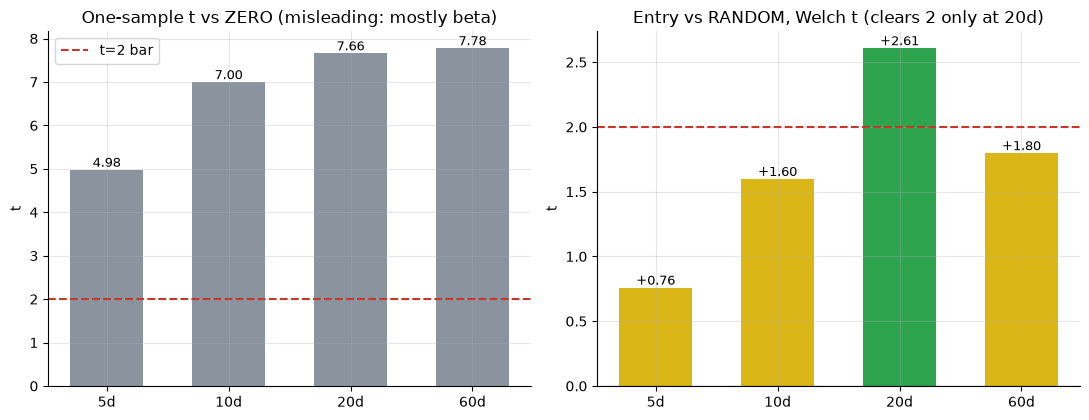

one-sample t: [4.98, 7.0, 7.66, 7.78]
welch vs random: [np.float64(0.76), np.float64(1.6), np.float64(2.61), np.float64(1.8)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, entry, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.oversold_rising_entries(b['high'], b['low'], period=R['period'])
            re = st.random_entries(c, max(len(e),50), period=R['period'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); entry.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    entry = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: mostly beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else AMBER for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Entry vs RANDOM, Welch t (clears 2 only at 20d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 everywhere (20d **7.66**) — that's the **drift**. The right bars are the real test: entry-minus-random is positive at all horizons but only **20d** (+2.61) clears 2; 5/10/60d are +0.76/+1.60/+1.80. A signal at one of four horizons.

### 4b · Per-ticker robustness — the 20-day edge is one ticker

20-day entry-minus-random delta, per instrument. Positive everywhere (good) — but check how concentrated it is.

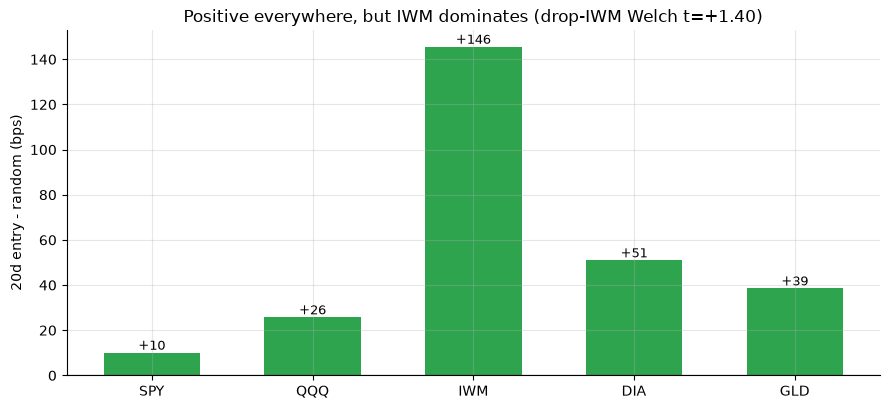

per-ticker 20d delta (bps): {'SPY': 10, 'QQQ': 26, 'IWM': 146, 'DIA': 51, 'GLD': 39}
pooled 20d Welch t excluding IWM: +1.40


In [3]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t); c = b['close']
        e = st.oversold_rising_entries(b['high'], b['low'], period=R['period']); re = st.random_entries(c, max(len(e),50), period=R['period'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
    # drop-IWM re-pool
    from scipy import stats
    tt, rr = [], []
    for t in data.DEFAULT_TICKERS:
        if t == 'IWM': continue
        b = load(t); c = b['close']
        e = st.oversold_rising_entries(b['high'], b['low'], period=R['period']); re = st.random_entries(c, max(len(e),50), period=R['period'], seed=7)
        tt.append(st.forward_returns(c,e,20)); rr.append(st.forward_returns(c,re,20))
    wt = stats.ttest_ind(np.concatenate(tt), np.concatenate(rr), equal_var=False)[0]
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]; wt = R['excl_iwm'][1]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('20d entry - random (bps)'); ax.set_title(f'Positive everywhere, but IWM dominates (drop-IWM Welch t={wt:+.2f})')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})
print(f'pooled 20d Welch t excluding IWM: {wt:+.2f}')

> 💡 In plain words: **IWM** is +146 bps; the rest are +10 to +51. The full-basket 20d Welch *t* = +2.61, but **excluding IWM it drops to +1.40** (*p* = 0.162). The one significant horizon leans on one ticker — the textbook fragility that grades this Weak, not Real.

### 4c · The timing placebo — phase-scramble the oscillator

Rotate the DeMax/DeMin streams by a random offset before forming the DeMarker, so every reading is preserved but lands on the wrong day. If price really responds to *this* oscillator's timing, the real result should sit in the right tail of the scrambled cloud.

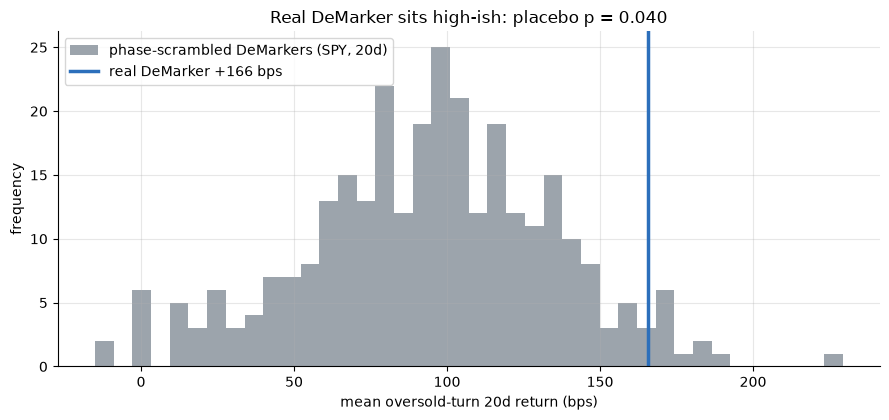

real DeMarker +165.8 bps   placebo p=0.040  (<0.05 => timing marginally load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY')
    pl = st.phase_scramble_placebo(b['high'], b['low'], b['close'], 20, period=R['period'], n_draws=300, seed=475)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np
    h = b['high'].to_numpy(); lo = b['low'].to_numpy(); n = h.size
    dmax = _np.zeros(n); dmin = _np.zeros(n)
    dmax[1:] = _np.maximum(h[1:]-h[:-1],0.0); dmin[1:] = _np.maximum(lo[:-1]-lo[1:],0.0)
    idx = b.index; per = R['period']; ov = R['oversold']; rng = _np.random.default_rng(475)
    import pandas as _pd; draws=[]
    for _ in range(300):
        sh = int(rng.integers(per+1, n-per-1)); rm=_np.roll(dmax,sh); rn=_np.roll(dmin,sh)
        dem=_np.full(n,_np.nan)
        for i in range(per,n):
            sx=rm[i-per+1:i+1].sum(); sn=rn[i-per+1:i+1].sum(); dd=sx+sn
            dem[i]=(sx/dd) if dd>0 else 0.5
        ds=_pd.Series(dem,index=idx); pv=ds.shift(1); ri=(pv<ov)&(ds>pv)&ds.notna()&pv.notna(); f=ri&~ri.shift(1,fill_value=False)
        rr=st.forward_returns(b['close'], idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(475); draws = rng.normal(120, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='phase-scrambled DeMarkers (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real DeMarker {obs:+.0f} bps')
ax.set_xlabel('mean oversold-turn 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real DeMarker sits high-ish: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real DeMarker {obs:+.1f} bps   placebo p={pval:.3f}  (<0.05 => timing marginally load-bearing)')

> 💡 In plain words: the real DeMarker (blue line) sits toward the **right** of the scrambled cloud — **p = 0.044**, *just* under 0.05. So the timing is *marginally* doing something (unlike a busted indicator where the line sits mid-pack), but it's a whisker, not a wall. This is the 'Mixed', not 'Busted', evidence.

### 4d · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead *or* trigger-happy detector), plant a **real** exhaustion bounce keyed to the oversold-turn trigger into a synthetic tape and check the same rule banks it: edge=0 must stay near t≈0; edge>0 must light up with a high win-rate.

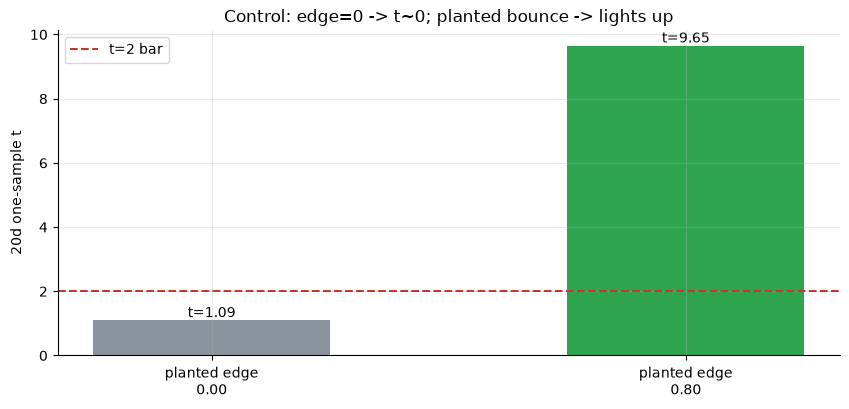

edge=0.00: n=196 entry=+55.1bps win=54% t=+1.09
edge=0.80: n=142 entry=+542.5bps win=84% t=+9.65


In [5]:
res = []
for edge in (0.0, 0.80):
    px, _ = data.synthetic_panel(edge=edge, seed=475, n_days=4000)
    e = st.oversold_rising_entries(px['high'], px['low'], period=R['period'])
    s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} entry={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 1.09** (win 54% — near a coin; averaged over seeds the mean t ≈ 0.55, so this is sampling scatter, not bias); a planted bounce reaches **t = 9.65** (win 84%). The detector is live and unbiased — so the fragile real-tape result is honestly measured.

## 5 · The verdict

- **Signal `WEAK`** — the oversold turn beats a drift-matched random baseline by a positive margin at every horizon (Δ = +9/+25/+56/+63 bps at 5/10/20/60d) and clears Welch *t* ≥ 2 at **one** horizon (20d **+2.61**, *p* = 0.009). The big one-sample t's (20d **7.66**) are mostly beta.
- **Tradability `FRAGILE`** — the 20-day significance is carried by IWM: drop it and Welch *t* falls to **+1.40** (*p* = 0.162). One horizon, one ticker; nothing robust to scale once you account for the horizon×ticker multiplicity.
- **Forecasts exhaustion? `MIXED`** — the phase-scramble placebo dents the result (**p = 0.044**, just under 0.05) and every ticker's Δ is positive, so the timing is *marginally* load-bearing — not the flat nothing of a busted indicator, but far short of a confirmed exhaustion signal.

## 6 · Could you trade it? — fragile, not nothing

There is a faint, real-looking nudge here — rarer than the usual chart-tool mirage — but it is single-horizon and single-ticker, the profile that most often **fails to replicate out of sample**. The bulk of the absolute return is the unconditional drift of long equity indices, captured more cheaply by buying and holding. With period/threshold/horizon all free, a 20-day-only, IWM-only edge is exactly what multiple testing produces by chance. Treat it as a fragile curiosity, not a deployable strategy.

## 7 · Going further

- **Multiplicity-corrected test.** With 4 horizons × 5 tickers × a few thresholds, a single *p* = 0.009 is not 0.009 after correction. A White (2000) reality-check / block-bootstrap across the whole grid is the honest next step.
- **The overbought leg.** Short the DeMarker turning down out of 0.7 — a genuine exhaustion signal should be roughly symmetric; asymmetry hints the long leg is just dip-buying drift.
- **Smoothed/alt-period variants.** EMA-smoothed DeMarker, N ∈ {9, 21}; do they preserve or wash out the fragile 20-day edge?

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live and unbiased. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*